# Population density

People per km² per 0.5° grid cell, sourced from **[JRC GHS-POP R2023A](https://ghsl.jrc.ec.europa.eu/download.php?ds=pop)** — the Global Human Settlement Layer population count raster at 30 arcsec (~1 km) resolution in WGS84 (EPSG:4326). Higher = denser. Ocean cells are masked to `NaN` using `is_land` from `grid.nc`.

GHS-POP ships as a single global GeoTIFF per five-year epoch (~460 MB zipped, ~7 GB uncompressed as float64). Values are **population count per source pixel**, so aggregating to 0.5° requires a `sum` over all source pixels falling into each atlas cell, then a divide by cell area (which varies by latitude) to get density.

The source raster is 43202 × 21384 at 30 arcsec, covering ±180.01° longitude and ±89.10° latitude — slightly overhanging the antimeridian and stopping short of the poles (no data past ±89.1°). Its pixel centres don't align to the atlas 0.5° cell boundaries, so instead of a naive coarsen we let `rasterio.warp.reproject` with `Resampling.sum` do the binning. `sum` conserves total population count: every source pixel contributes to every destination cell it overlaps, weighted by overlap area. GDAL streams the source raster internally, so peak memory stays modest.

In [10]:
import zipfile

import numpy as np
import rasterio
import xarray as xr
from rasterio.windows import Window
from tqdm.auto import tqdm

from common import RAW_DIR,PROCESSED_DIR, download, load_grid, plot_map, save_variable, compute_population_density_score

VARIABLE = 'population_density'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)
intermediate = PROCESSED_DIR / '_population_density.nc'

YEAR = 2025  # latest modelled epoch in GHS-POP R2023A (2030 also available but purely projected)
PRODUCT = f'GHS_POP_E{YEAR}_GLOBE_R2023A_4326_30ss_V1_0'

grid = load_grid()
NLAT, NLON = grid.lat.size, grid.lon.size
RES = float(grid.lat.diff('lat').mean())  # degrees per atlas cell (0.5 for the default grid)
LAT_MIN = float(grid.lat.min()) - RES / 2   # southern edge of the atlas grid
LON_MIN = float(grid.lon.min()) - RES / 2   # western edge of the atlas grid
print(f'atlas grid: {NLAT} x {NLON} at {RES}° (lat {LAT_MIN}..{LAT_MIN + NLAT * RES}, lon {LON_MIN}..{LON_MIN + NLON * RES})')

atlas grid: 360 x 720 at 0.5° (lat -90.0..90.0, lon -180.0..180.0)


## 1. Fetch raw data

One zipped GeoTIFF (~460 MB) from the JRC open-data FTP. First run: several minutes on a home connection. Re-runs: instant.

In [11]:
BASE = 'https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_POP_GLOBE_R2023A'
zip_path = variable_raw / f'{PRODUCT}.zip'
tif_path = variable_raw / f'{PRODUCT}.tif'

if not tif_path.exists():
    if not zip_path.exists():
        url = f'{BASE}/GHS_POP_E{YEAR}_GLOBE_R2023A_4326_30ss/V1-0/{PRODUCT}.zip'
        print(f'downloading {url}')
        await download(url, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extract(f'{PRODUCT}.tif', variable_raw)

print(f'{tif_path.name}: {tif_path.stat().st_size / 1024**3:.2f} GB')

GHS_POP_E2025_GLOBE_R2023A_4326_30ss_V1_0.tif: 0.36 GB


## 2. Bin-sum source pixels into atlas cells

For each source pixel we compute the integer index of the atlas cell whose centre it is nearest to, then accumulate the pixel's count into that cell. `row_idx` is monotonic along the source y-axis (latitude decreases as row increases), so all source rows that map to the same atlas row form one contiguous block on disk. We iterate over those blocks: for each atlas row we read its ~60 source rows in one shot, sum along the y-axis, and bin along x with `np.bincount`.

Compared to `rasterio.warp.reproject(..., Resampling.sum)` this is an order of magnitude faster (one plain sequential read, no warp pipeline) and reads its destination shape and extent from `grid.nc`, so a change in atlas resolution needs no code change. Trade-off: source pixels are hard-assigned to the cell containing their centre rather than area-weighted across the (up to 4) cells they overlap — at 60 × downsampling the boundary error is at most ~1/60 (1.7%) of a source pixel and averages out over the ~3600 pixels feeding each atlas cell.

In [12]:
counts = np.zeros((NLAT, NLON), dtype='float64')

with rasterio.open(tif_path) as src:
    assert src.crs.to_epsg() == 4326, f'expected EPSG:4326, got {src.crs}'

    # Per-pixel centres from the affine transform, then integer atlas cell index.
    src_lon = src.transform.c + src.transform.a * (np.arange(src.width) + 0.5)
    src_lat = src.transform.f + src.transform.e * (np.arange(src.height) + 0.5)
    col_idx = np.floor((src_lon - LON_MIN) / RES).astype(np.int64)
    row_idx = np.floor((src_lat - LAT_MIN) / RES).astype(np.int64)
    col_valid = (col_idx >= 0) & (col_idx < NLON)
    valid_cols = col_idx[col_valid]

    # row_idx is monotonic along y, so contiguous runs of equal values are the
    # source-row blocks that fold into a single atlas row.
    change_at = np.flatnonzero(np.diff(row_idx)) + 1
    starts = np.concatenate([[0], change_at])
    ends = np.concatenate([change_at, [src.height]])

    for s, e in tqdm(list(zip(starts, ends)), desc='atlas rows'):
        arow = int(row_idx[s])
        if arow < 0 or arow >= NLAT:
            continue
        block = src.read(1, window=Window(0, int(s), src.width, int(e - s)))
        block = np.nan_to_num(block, nan=0.0)
        row_sum = block.sum(axis=0)
        counts[arow] += np.bincount(valid_cols, weights=row_sum[col_valid], minlength=NLON)[:NLON]

pop_count = xr.DataArray(
    counts,
    coords={'lat': grid.lat.values, 'lon': grid.lon.values},
    dims=('lat', 'lon'),
    name='population_count',
)
print(f'global population sum: {pop_count.sum().item() / 1e9:.2f} billion')

atlas rows:   0%|          | 0/358 [00:00<?, ?it/s]

/var/folders/hq/d3n2t3r135gfw07crm1cqnrh0000gn/T/ipykernel_4444/1146048122.py:24: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  block = src.read(1, window=Window(0, int(s), src.width, int(e - s)))


global population sum: 8.19 billion


## 3. Convert count → density

A 0.5° × 0.5° cell at latitude θ covers approximately `(0.5 · 111.32)² · cos(θ) km²` — narrowing towards the poles. Divide the per-cell population count by that area to get people per km².

In [13]:
DEG_KM = 111.32  # length of one degree of latitude in km (spherical-earth approximation)

cell_area = (RES * DEG_KM) ** 2 * np.cos(np.deg2rad(pop_count.lat))
density = pop_count / cell_area
density.name = VARIABLE
density

<xarray.DataArray 'population_density' (lat: 360, lon: 720)> Size: 2MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(360, 720))
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

## 4. Mask ocean

`density` is already on `grid.lat` / `grid.lon` by construction — no interpolation needed. Just cast and apply the land mask.

In [14]:
values = (
    density.astype('float32')
    .rename(VARIABLE)
    .where(grid.is_land == 1)
)
values.attrs['units'] = 'people/km²'
values.attrs['source'] = 'JRC GHS-POP R2023A'
values.attrs['source_year'] = YEAR
values

<xarray.DataArray 'population_density' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(360, 720), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    units:        people/km²
    source:       JRC GHS-POP R2023A
    source_year:  2025

## 5. Plot

Population density spans several orders of magnitude, so plot `log10(density)` to keep megacities from washing out the rest of the map.

<Axes: title={'center': 'population_density'}, xlabel='longitude', ylabel='latitude'>

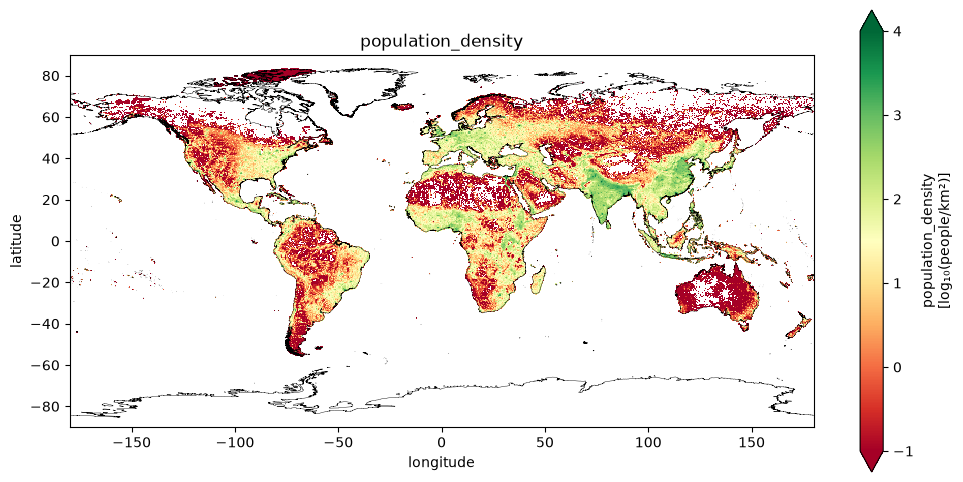

In [15]:
log_density = np.log10(values.where(values > 0))
log_density.attrs['units'] = 'log₁₀(people/km²)'
plot_map(log_density, vmin=-1, vmax=4)

## 6. Save Intermediate

In [16]:
values.to_netcdf(intermediate)
print(f'wrote {intermediate}')

wrote /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/processed/_population_density.nc


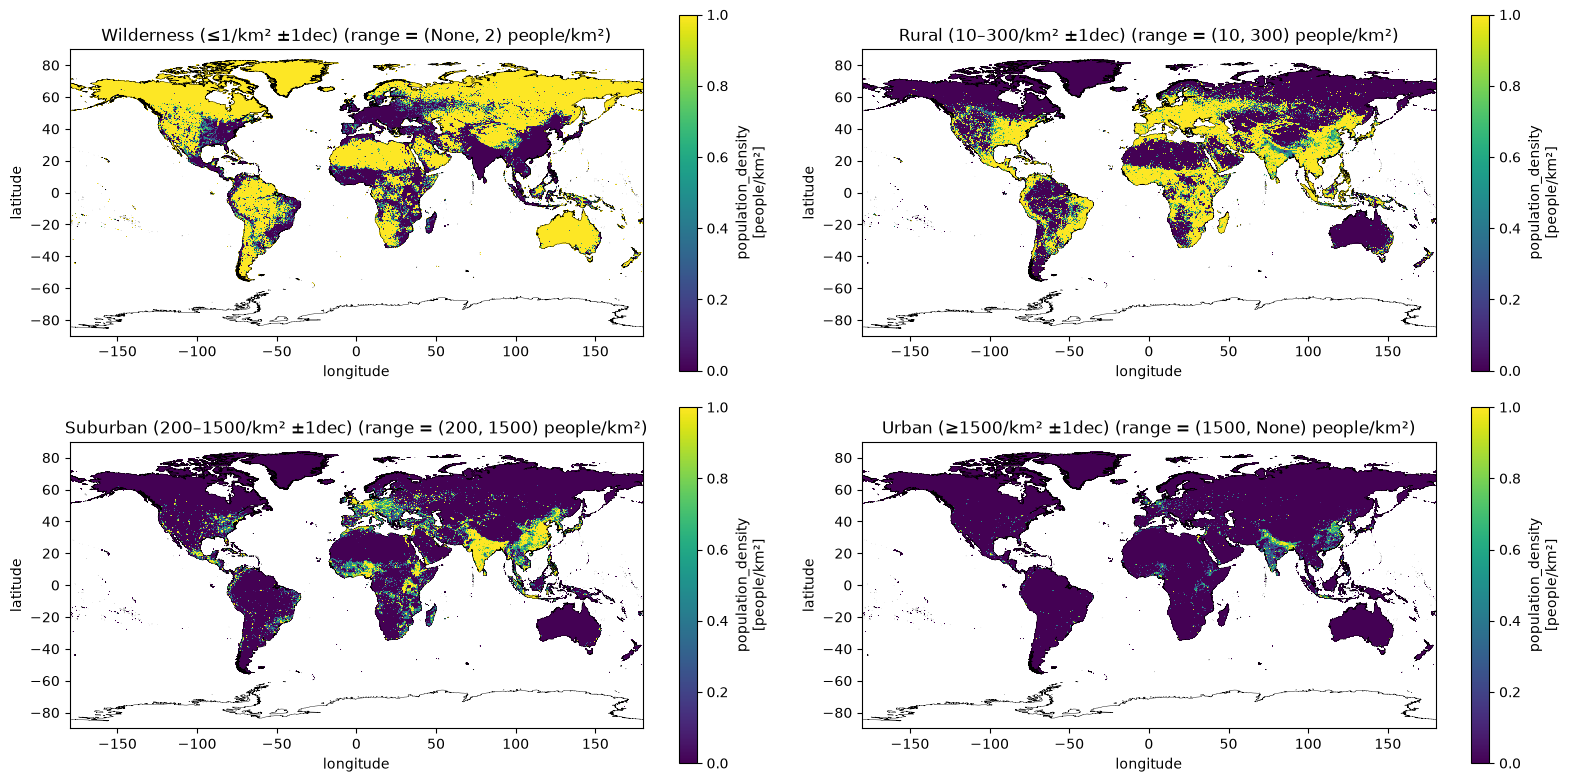

In [32]:
DENSITY_PROFILES = {
    'Wilderness (≤1/km² ±1dec)':     ((None, 2),    1.0),
    'Rural (10–300/km² ±1dec)':      ((10, 300),    1.0),
    'Suburban (200–1500/km² ±1dec)': ((200, 1500),  1.0),
    'Urban (≥1500/km² ±1dec)':       ((1500, None), 1.0),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, (label, (rng, tol_dec)) in zip(axes.flat, DENSITY_PROFILES.items()):
    score = compute_population_density_score(intermediate, density_range=rng, tolerance_decades=tol_dec)
    plot_map(score, ax=ax, cmap='viridis', vmin=0, vmax=1,
             title=f"{label} (range = {rng} people/km²)")
plt.tight_layout()

# 8. Save Prefered Density Score


In [ ]:
score = compute_population_density_score(intermediate, tolerance_decades=1.0, **PRESETS['rural'])

out = save_variable(score, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/population_density.nc
